# RELDEC Orchestration Notebook



This notebook orchestrates end-to-end RELDEC experiments:

- training with checkpoint/resume

- evaluation vs flooding/random/round-robin baselines

- BER/FER/complexity plots



It uses the Python CLIs in the same folder:

- `train_reldec.py`

- `evaluate_reldec.py`

- `reldec_core.py`

## Run Modes



- `RUN_MODE = "smoke"`: quick validation, small sample counts.

- `RUN_MODE = "full"`: spec-scale experiments (long runtime).



For full experiments, expect long training/evaluation times, especially when target frame errors are set to 300 for each SNR point.

In [1]:
from __future__ import annotations



import concurrent.futures as cf

import csv

import json

import os

import re

import shlex

import subprocess

import sys

import threading

import time

from pathlib import Path



import matplotlib.pyplot as plt

import numpy as np

from IPython.display import clear_output, display



ROOT = Path.cwd()

if not (ROOT / "RELDEC").exists():

    ROOT = Path("/root/Research/RithvikDecoder/Decoder")



RELDEC_DIR = ROOT / "RELDEC"

TRAIN_SCRIPT = RELDEC_DIR / "train_reldec.py"

EVAL_SCRIPT = RELDEC_DIR / "evaluate_reldec.py"

RUNS_DIR = RELDEC_DIR / "notebook_runs"

RUNS_DIR.mkdir(parents=True, exist_ok=True)



PYTHON = Path(sys.executable)



required_paths = [RELDEC_DIR, TRAIN_SCRIPT, EVAL_SCRIPT]

for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(f"Missing required path: {path}")



print(f"Python executable: {PYTHON}")

print(f"Project root:      {ROOT}")

print(f"RELDEC dir:        {RELDEC_DIR}")

print(f"Runs dir:          {RUNS_DIR}")

Python executable: /root/.pyenv/versions/myenv/bin/python
Project root:      /root/Research/RithvikDecoder/Decoder
RELDEC dir:        /root/Research/RithvikDecoder/Decoder/RELDEC
Runs dir:          /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs


In [2]:
RUN_MODE = "full"  # switched to full-mode runs

RUN_TAG = time.strftime("%Y%m%d_%H%M%S")

CONTINUOUS_RUN_DIR = RUNS_DIR / "continuous_reldec"
TARGET_RUN_ROOT = CONTINUOUS_RUN_DIR / "active_run"
EVAL_ONLY_FROM_CHECKPOINTS = True
OVERWRITE_EVAL_RESULTS = True

CODES = ["wran"]
METHODS = ["flooding", "random", "round_robin", "reldec"]

MATRIX_OVERRIDES = {
    "ab": str(RELDEC_DIR / "matrices" / "H_AB_LDPC_500.csv"),
    "wran": str(RELDEC_DIR / "matrices" / "WRAN_irreg_384_256.csv"),
}

if RUN_MODE == "full":
    TRAIN_ARGS = {
        "episodes_per_snr": 2500,
        "checkpoint_every_episodes": 250,
        "log_every": 100,
        "max_episodes": None,
        "snr_override": {"wran": [3.0]},
    }

    EVAL_ARGS = {
        "target_frame_errors": 300,
        "max_frames": 10000,
        "snr_override": {"wran": [3.0]},
    }
else:
    TRAIN_ARGS = {
        "episodes_per_snr": 6,
        "checkpoint_every_episodes": 6,
        "log_every": 3,
        "max_episodes": 24,
        "snr_override": {"wran": [3.0]},
    }

    EVAL_ARGS = {
        "target_frame_errors": 8,
        "max_frames": 500,
        "snr_override": {"wran": [3.0]},
    }

BASE_SEED = 17
RESUME_IF_AVAILABLE = True

CONTINUOUS_RUN_DIR.mkdir(parents=True, exist_ok=True)

if EVAL_ONLY_FROM_CHECKPOINTS:
    RUN_ROOT = TARGET_RUN_ROOT

    if not RUN_ROOT.exists():
        raise FileNotFoundError(f"Target run root not found: {RUN_ROOT}")
else:
    RUN_ROOT = RUNS_DIR / f"run_{RUN_TAG}_{RUN_MODE}"
    RUN_ROOT.mkdir(parents=True, exist_ok=True)

print(f"RUN_MODE:                   {RUN_MODE}")
print(f"RUN_ROOT:                   {RUN_ROOT}")
print(f"CONTINUOUS_RUN_DIR:         {CONTINUOUS_RUN_DIR}")
print(f"EVAL_ONLY_FROM_CHECKPOINTS: {EVAL_ONLY_FROM_CHECKPOINTS}")
print(f"OVERWRITE_EVAL_RESULTS:     {OVERWRITE_EVAL_RESULTS}")
print(f"CODES:                      {CODES}")
print(f"METHODS:                    {METHODS}")
print(f"MATRIX_OVERRIDES:           {MATRIX_OVERRIDES}")

RUN_MODE:                   full
RUN_ROOT:                   /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run
CONTINUOUS_RUN_DIR:         /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec
EVAL_ONLY_FROM_CHECKPOINTS: True
OVERWRITE_EVAL_RESULTS:     True
CODES:                      ['wran']
METHODS:                    ['flooding', 'random', 'round_robin', 'reldec']
MATRIX_OVERRIDES:           {'ab': '/root/Research/RithvikDecoder/Decoder/RELDEC/matrices/H_AB_LDPC_500.csv', 'wran': '/root/Research/RithvikDecoder/Decoder/RELDEC/matrices/WRAN_irreg_384_256.csv'}


In [4]:
def _cmd_to_str(cmd: list[str]) -> str:

    return " ".join(shlex.quote(str(x)) for x in cmd)





def run_cmd(cmd: list[str], cwd: Path = ROOT) -> subprocess.CompletedProcess:

    printable = _cmd_to_str(cmd)

    print(f"$ {printable}")

    completed = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)

    if completed.stdout.strip():

        print(completed.stdout)

    if completed.returncode != 0:

        if completed.stderr.strip():

            print(completed.stderr)

        raise RuntimeError(f"Command failed ({completed.returncode}): {printable}")

    return completed





def run_cmd_stream(

    cmd: list[str],

    cwd: Path = ROOT,

    env_overrides: dict | None = None,

    on_line=None,

) -> subprocess.CompletedProcess:

    printable = _cmd_to_str(cmd)

    print(f"$ {printable}")



    env = dict(os.environ)

    if env_overrides:

        env.update(env_overrides)



    proc = subprocess.Popen(

        cmd,

        cwd=cwd,

        text=True,

        stdout=subprocess.PIPE,

        stderr=subprocess.STDOUT,

        env=env,

        bufsize=1,

    )



    captured: list[str] = []

    assert proc.stdout is not None

    for line in proc.stdout:

        line = line.rstrip("\n")

        captured.append(line)

        print(line)

        if on_line is not None:

            on_line(line)



    rc = proc.wait()

    output = "\n".join(captured)

    if rc != 0:

        raise RuntimeError(f"Command failed ({rc}): {printable}\n{output}")



    return subprocess.CompletedProcess(cmd, rc, stdout=output, stderr="")





def train_code(code: str, seed: int) -> dict:

    code_root = RUN_ROOT / code

    ckpt_dir = code_root / "checkpoints"

    ckpt_dir.mkdir(parents=True, exist_ok=True)

    latest_ckpt = ckpt_dir / "checkpoint_latest.npz"



    cmd = [

        str(PYTHON),

        str(TRAIN_SCRIPT),

        "--code",

        code,

        "--episodes-per-snr",

        str(TRAIN_ARGS["episodes_per_snr"]),

        "--checkpoint-dir",

        str(ckpt_dir),

        "--checkpoint-every-episodes",

        str(TRAIN_ARGS["checkpoint_every_episodes"]),

        "--log-every",

        str(TRAIN_ARGS["log_every"]),

        "--seed",

        str(seed),

    ]



    if TRAIN_ARGS["max_episodes"] is not None:

        cmd += ["--max-episodes", str(TRAIN_ARGS["max_episodes"])]



    snr_override = TRAIN_ARGS["snr_override"]

    if snr_override is not None and code in snr_override:

        cmd += ["--snr-db"] + [str(v) for v in snr_override[code]]



    if RESUME_IF_AVAILABLE and latest_ckpt.exists():

        cmd += ["--resume", str(latest_ckpt)]



    run_cmd(cmd)



    return {

        "code": code,

        "code_root": code_root,

        "checkpoint_dir": ckpt_dir,

        "checkpoint_latest": latest_ckpt,

        "q_table_npy": ckpt_dir / "q_table_final.npy",

        "summary_json": ckpt_dir / "training_summary.json",

    }





def evaluate_code(code: str, q_table_path: Path, seed: int, methods: list[str]) -> dict:

    code_root = RUN_ROOT / code

    result_dir = code_root / "results"

    result_dir.mkdir(parents=True, exist_ok=True)

    csv_path = result_dir / "eval.csv"

    json_path = result_dir / "eval.json"



    cmd = [

        str(PYTHON),

        str(EVAL_SCRIPT),

        "--code",

        code,

        "--q-table",

        str(q_table_path),

        "--methods",

        *methods,

        "--target-frame-errors",

        str(EVAL_ARGS["target_frame_errors"]),

        "--max-frames",

        str(EVAL_ARGS["max_frames"]),

        "--seed",

        str(seed),

        "--output-csv",

        str(csv_path),

        "--output-json",

        str(json_path),

    ]



    snr_override = EVAL_ARGS["snr_override"]

    if snr_override is not None and code in snr_override:

        cmd += ["--snr-db"] + [str(v) for v in snr_override[code]]



    run_cmd(cmd)

    return {

        "eval_csv": csv_path,

        "eval_json": json_path,

    }





def evaluate_code_streaming(

    code: str,

    q_table_path: Path,

    seed: int,

    methods: list[str],

    on_line=None,

) -> dict:

    code_root = RUN_ROOT / code

    result_dir = code_root / "results"

    result_dir.mkdir(parents=True, exist_ok=True)

    csv_path = result_dir / "eval.csv"

    json_path = result_dir / "eval.json"



    cmd = [

        str(PYTHON),

        str(EVAL_SCRIPT),

        "--code",

        code,

        "--q-table",

        str(q_table_path),

        "--methods",

        *methods,

        "--target-frame-errors",

        str(EVAL_ARGS["target_frame_errors"]),

        "--max-frames",

        str(EVAL_ARGS["max_frames"]),

        "--seed",

        str(seed),

        "--output-csv",

        str(csv_path),

        "--output-json",

        str(json_path),

    ]



    snr_override = EVAL_ARGS["snr_override"]

    if snr_override is not None and code in snr_override:

        cmd += ["--snr-db"] + [str(v) for v in snr_override[code]]



    run_cmd_stream(

        cmd,

        env_overrides={"OMP_NUM_THREADS": "1"},

        on_line=on_line,

    )

    return {

        "eval_csv": csv_path,

        "eval_json": json_path,

    }





def _parse_value(raw: str):

    lower = raw.lower()

    if lower in {"true", "false"}:

        return lower == "true"

    try:

        if any(ch in raw for ch in [".", "e", "E"]):

            return float(raw)

        return int(raw)

    except ValueError:

        return raw





def read_eval_csv(csv_path: Path) -> list[dict]:

    rows: list[dict] = []

    with open(csv_path, newline="", encoding="utf-8") as fh:

        reader = csv.DictReader(fh)

        for row in reader:

            parsed = {k: _parse_value(v) for k, v in row.items()}

            parsed["eval_csv"] = str(csv_path)

            rows.append(parsed)

    return rows





def parse_live_eval_line_factory(code: str, shared_rows: list[dict], lock: threading.Lock):

    snr_pat = re.compile(r"^\[eval\]\s+snr=([0-9.]+)\s+dB")

    method_pat = re.compile(

        r"^\s*-\s+(\w+)\s+frames=\s*(\d+)\s+FER=([0-9eE+\-.]+)\s+BER=([0-9eE+\-.]+)\s+avg_msgs=([0-9eE+\-.]+)"

    )

    current_snr: float | None = None



    def _on_line(line: str) -> None:

        nonlocal current_snr



        m = snr_pat.search(line)

        if m:

            current_snr = float(m.group(1))

            return



        m = method_pat.search(line)

        if m and current_snr is not None:

            row = {

                "code": code,

                "method": m.group(1).lower(),

                "snr_db": current_snr,

                "frames": int(m.group(2)),

                "fer": float(m.group(3)),

                "ber": float(m.group(4)),

                "avg_messages": float(m.group(5)),

            }



            with lock:

                replaced = False

                for i, old in enumerate(shared_rows):

                    if (

                        str(old["code"]).lower() == row["code"]

                        and str(old["method"]).lower() == row["method"]

                        and float(old["snr_db"]) == float(row["snr_db"])

                    ):

                        shared_rows[i] = row

                        replaced = True

                        break

                if not replaced:

                    shared_rows.append(row)



    return _on_line





def plot_metric_panels(rows: list[dict], codes: list[str], methods: list[str], title_suffix: str = "") -> None:

    if not rows:

        raise ValueError("No rows available. Run orchestration first.")



    metric_specs = [

        ("ber", "BER", True),

        ("fer", "FER", True),

        ("avg_messages", "Avg CN→VN Messages", False),

    ]



    n_rows = len(codes)

    n_cols = len(metric_specs)

    fig, axes = plt.subplots(

        n_rows,

        n_cols,

        figsize=(5.5 * n_cols, 4.0 * n_rows),

        squeeze=False,

    )



    for r, code in enumerate(codes):

        code_rows = [row for row in rows if str(row["code"]).lower() == code.lower()]



        for c, (metric_key, metric_label, logy) in enumerate(metric_specs):

            ax = axes[r][c]

            for method in methods:

                method_rows = [

                    row for row in code_rows if str(row["method"]).lower() == method.lower()

                ]

                if not method_rows:

                    continue



                points = sorted((float(row["snr_db"]), float(row[metric_key])) for row in method_rows)

                x = [p[0] for p in points]

                y = [max(p[1], 1e-12) if logy else p[1] for p in points]



                if logy:

                    ax.semilogy(x, y, marker="o", linewidth=2.0, label=method)

                else:

                    ax.plot(x, y, marker="o", linewidth=2.0, label=method)



            ax.set_title(f"{code.upper()} | {metric_label}")

            ax.set_xlabel("Eb/N0 (dB)")

            ax.set_ylabel(metric_label)

            ax.grid(True, which="both", linestyle="--", alpha=0.35)



            if c == n_cols - 1:

                ax.legend(loc="best")



    title = f"RELDEC Orchestration Results ({RUN_MODE})"

    if title_suffix:

        title = f"{title} - {title_suffix}"

    fig.suptitle(title, fontsize=14)

    fig.tight_layout()

    plt.show()

Parallel orchestration progress: 0/2 complete


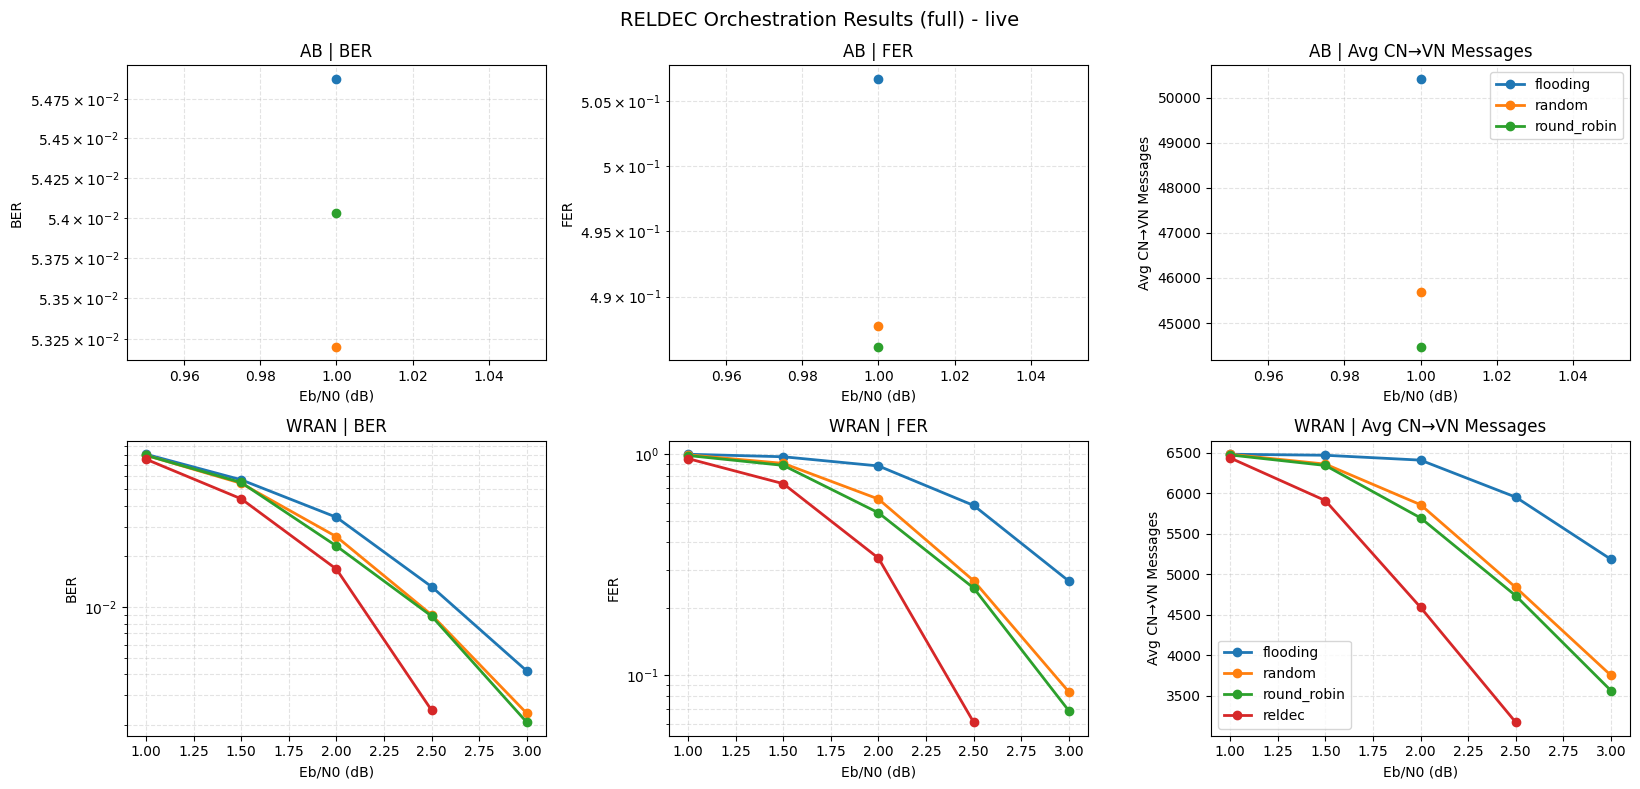

In [ ]:
def orchestrate_one_code_parallel(code: str, idx: int, live_rows: list[dict], lock: threading.Lock) -> dict:

    print("=" * 90)

    print(f"Orchestrating code: {code}")



    train_seed = BASE_SEED + idx

    eval_seed = BASE_SEED + 1000 + idx



    train_info = train_code(code=code, seed=train_seed)



    line_cb = parse_live_eval_line_factory(code=code, shared_rows=live_rows, lock=lock)

    eval_info = evaluate_code_streaming(

        code=code,

        q_table_path=train_info["checkpoint_latest"],

        seed=eval_seed,

        methods=METHODS,

        on_line=line_cb,

    )



    return {**train_info, **eval_info}





live_rows: list[dict] = []

artifacts = []

live_lock = threading.Lock()



max_workers = min(len(CODES), 2)



with cf.ThreadPoolExecutor(max_workers=max_workers) as executor:

    futures = [

        executor.submit(orchestrate_one_code_parallel, code, idx, live_rows, live_lock)

        for idx, code in enumerate(CODES)

    ]



    while True:

        done = sum(f.done() for f in futures)



        with live_lock:

            snapshot = list(live_rows)



        clear_output(wait=True)

        print(f"Parallel orchestration progress: {done}/{len(futures)} complete")

        if snapshot:

            try:

                plot_metric_panels(snapshot, CODES, METHODS, title_suffix="live")

            except Exception as exc:

                print(f"Live plotting warning: {exc}")

                print(f"Current parsed points: {len(snapshot)}")

        else:

            print("Waiting for first evaluation points...")



        if done == len(futures):

            break



        time.sleep(2.0)



    artifacts = [f.result() for f in futures]



print("=" * 90)

print("Parallel orchestration complete.")

for item in artifacts:

    print(f"- {item['code']}: checkpoints={item['checkpoint_dir']} results={item['eval_csv']}")

In [5]:
all_rows: list[dict] = []

for item in artifacts:

    all_rows.extend(read_eval_csv(item["eval_csv"]))



all_rows = sorted(all_rows, key=lambda r: (str(r["code"]), float(r["snr_db"]), str(r["method"])))



try:

    import pandas as pd



    df = pd.DataFrame(all_rows)

    cols = [

        "code",

        "method",

        "snr_db",

        "frames",

        "frame_errors",

        "ber",

        "fer",

        "avg_messages",

        "avg_iterations",

    ]

    display(df[cols])

except Exception as exc:

    print(f"pandas display unavailable ({exc}); printing rows instead")

    for row in all_rows:

        print(row)

,code,method,snr_db,frames,frame_errors,ber,fer,avg_messages,avg_iterations
0,ab,flooding,1.0,11,8,0.069818,0.727273,58636.363636,39.090909
1,ab,random,1.0,15,8,0.055867,0.533333,47300.000000,31.533333
2,ab,reldec,1.0,13,8,0.069692,0.615385,54000.000000,36.000000
3,ab,round_robin,1.0,15,8,0.052667,0.533333,48600.000000,32.400000
4,ab,flooding,1.5,35,8,0.026686,0.228571,31028.571429,20.685714
5,ab,random,1.5,62,8,0.012613,0.129032,21338.709677,14.225806
6,ab,reldec,1.5,55,8,0.015018,0.145455,20372.727273,13.581818
7,ab,round_robin,1.5,44,8,0.016864,0.181818,21136.363636,14.090909
8,ab,flooding,2.0,115,8,0.007270,0.069565,19239.130435,12.826087
9,ab,random,2.0,120,5,0.003150,0.041667,12875.000000,8.583333


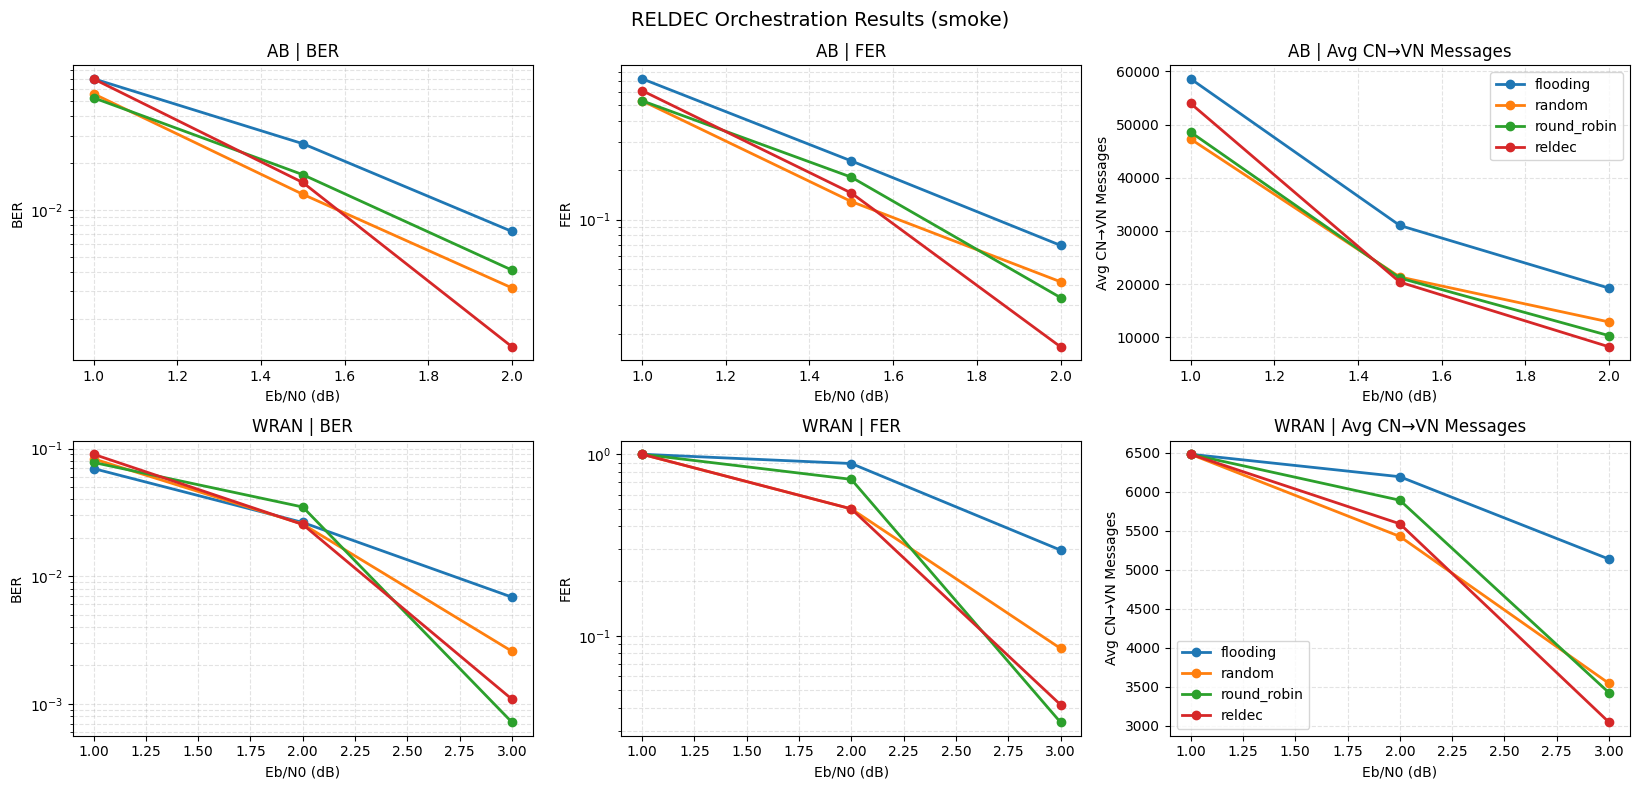

In [6]:
def plot_metric_panels(rows: list[dict], codes: list[str], methods: list[str]) -> None:

    if not rows:

        raise ValueError("No rows available. Run orchestration first.")



    metric_specs = [

        ("ber", "BER", True),

        ("fer", "FER", True),

        ("avg_messages", "Avg CN→VN Messages", False),

    ]



    n_rows = len(codes)

    n_cols = len(metric_specs)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.0 * n_rows), squeeze=False)



    for r, code in enumerate(codes):

        code_rows = [row for row in rows if str(row["code"]).lower() == code.lower()]



        for c, (metric_key, metric_label, logy) in enumerate(metric_specs):

            ax = axes[r][c]

            for method in methods:

                method_rows = [

                    row for row in code_rows if str(row["method"]).lower() == method.lower()

                ]

                if not method_rows:

                    continue



                points = sorted((float(row["snr_db"]), float(row[metric_key])) for row in method_rows)

                x = [p[0] for p in points]

                y = [max(p[1], 1e-12) if logy else p[1] for p in points]



                if logy:

                    ax.semilogy(x, y, marker="o", linewidth=2.0, label=method)

                else:

                    ax.plot(x, y, marker="o", linewidth=2.0, label=method)



            ax.set_title(f"{code.upper()} | {metric_label}")

            ax.set_xlabel("Eb/N0 (dB)")

            ax.set_ylabel(metric_label)

            ax.grid(True, which="both", linestyle="--", alpha=0.35)



            if c == n_cols - 1:

                ax.legend(loc="best")



    fig.suptitle(f"RELDEC Orchestration Results ({RUN_MODE})", fontsize=14)

    fig.tight_layout()

    plt.show()





plot_metric_panels(all_rows, CODES, METHODS)

In [5]:
def recover_artifacts_from_disk(run_root: Path, codes: list[str]) -> list[dict]:

    recovered: list[dict] = []

    for code in codes:

        code_root = run_root / code

        ckpt_dir = code_root / "checkpoints"

        result_dir = code_root / "results"



        checkpoint_latest = ckpt_dir / "checkpoint_latest.npz"

        checkpoint_final = ckpt_dir / "checkpoint_final.npz"

        q_table_npy = ckpt_dir / "q_table_final.npy"

        training_summary = ckpt_dir / "training_summary.json"

        eval_csv = result_dir / "eval.csv"

        eval_json = result_dir / "eval.json"



        recovered.append(

            {

                "code": code,

                "code_root": code_root,

                "checkpoint_dir": ckpt_dir,

                "checkpoint_latest": checkpoint_latest,

                "checkpoint_final": checkpoint_final,

                "q_table_npy": q_table_npy,

                "summary_json": training_summary,

                "eval_csv": eval_csv,

                "eval_json": eval_json,

                "training_saved": checkpoint_latest.exists() and checkpoint_final.exists() and q_table_npy.exists(),

                "evaluation_saved": eval_csv.exists() and eval_json.exists(),

            }

        )



    return recovered





def _run_has_saved_training(run_root: Path, codes: list[str]) -> bool:

    for code in codes:

        ckpt = run_root / code / "checkpoints" / "checkpoint_latest.npz"

        if ckpt.exists():

            return True

    return False





def _pick_latest_full_run_with_training(runs_dir: Path, codes: list[str]) -> Path | None:

    candidates = sorted([p for p in runs_dir.glob("run_*_full") if p.is_dir()])

    candidates = [p for p in candidates if _run_has_saved_training(p, codes)]

    if not candidates:

        return None

    return candidates[-1]





# Prefer RUN_ROOT only if it already contains training artifacts.

if RUN_ROOT.exists() and _run_has_saved_training(RUN_ROOT, CODES):

    active_run_root = RUN_ROOT

else:

    active_run_root = _pick_latest_full_run_with_training(RUNS_DIR, CODES)



if active_run_root is None:

    raise FileNotFoundError(f"No saved full run with checkpoints found under {RUNS_DIR}")



# If notebook variable artifacts is missing/empty (kernel restart case), recover from disk.

if "artifacts" not in globals() or not isinstance(artifacts, list) or len(artifacts) == 0:

    artifacts = recover_artifacts_from_disk(active_run_root, CODES)

else:

    # Merge runtime artifacts with filesystem status flags.

    disk = {item["code"]: item for item in recover_artifacts_from_disk(active_run_root, CODES)}

    merged: list[dict] = []

    for item in artifacts:

        code = item["code"]

        d = disk.get(code, {})

        merged.append({**d, **item, "training_saved": d.get("training_saved", False), "evaluation_saved": d.get("evaluation_saved", False)})

    artifacts = merged



manifest = {

    "run_mode": "full",

    "run_root": str(active_run_root),

    "codes": CODES,

    "methods": METHODS,

    "train_args": TRAIN_ARGS,

    "eval_args": EVAL_ARGS,

    "recovered_without_rerun": True,

    "artifacts": [

        {

            "code": item["code"],

            "checkpoint_dir": str(item["checkpoint_dir"]),

            "checkpoint_latest": str(item["checkpoint_latest"]),

            "checkpoint_final": str(item["checkpoint_final"]),

            "q_table_npy": str(item["q_table_npy"]),

            "training_summary_json": str(item["summary_json"]),

            "eval_csv": str(item["eval_csv"]),

            "eval_json": str(item["eval_json"]),

            "training_saved": bool(item["training_saved"]),

            "evaluation_saved": bool(item["evaluation_saved"]),

        }

        for item in artifacts

    ],

}



manifest_path = active_run_root / "orchestration_manifest.json"

recovery_manifest_path = active_run_root / "orchestration_recovery_manifest.json"

manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

recovery_manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")



print(f"Recovered run root: {active_run_root}")

print(f"Manifest written: {manifest_path}")

print(f"Recovery manifest written: {recovery_manifest_path}")

for item in manifest["artifacts"]:

    print(

        f"- {item['code']}: training_saved={item['training_saved']} "

        f"evaluation_saved={item['evaluation_saved']}"

    )

Recovered run root: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/run_20260319_203448_full
Manifest written: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/run_20260319_203448_full/orchestration_manifest.json
Recovery manifest written: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/run_20260319_203448_full/orchestration_recovery_manifest.json
- ab: training_saved=True evaluation_saved=False
- wran: training_saved=True evaluation_saved=False
